# Lineare PCA

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
from sklearn.datasets import load_iris
from scipy.stats import pearsonr 

# Korrelation zwischen einzelnen Merkmalen und Targetmerkmalen
iris = load_iris()
X = iris.data
y = iris.target
for fid in (0, 1, 2, 3): 
    idx = np.where( (y == 0) | (y == 1) )
    x = X[idx]
    x = x[:, fid]
    print(iris.feature_names[fid], pearsonr(x, y[idx])[0])

sepal length (cm) 0.7282901487462142
sepal width (cm) -0.690684336405237
petal length (cm) 0.969990231486349
petal width (cm) 0.9603069679112729


C:\Users\gilg\AppData\Local\Temp\ipykernel_9024\806889094.py:20: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label = Y_target_names[i],  c=color, lw=2, cmap=CMAP)


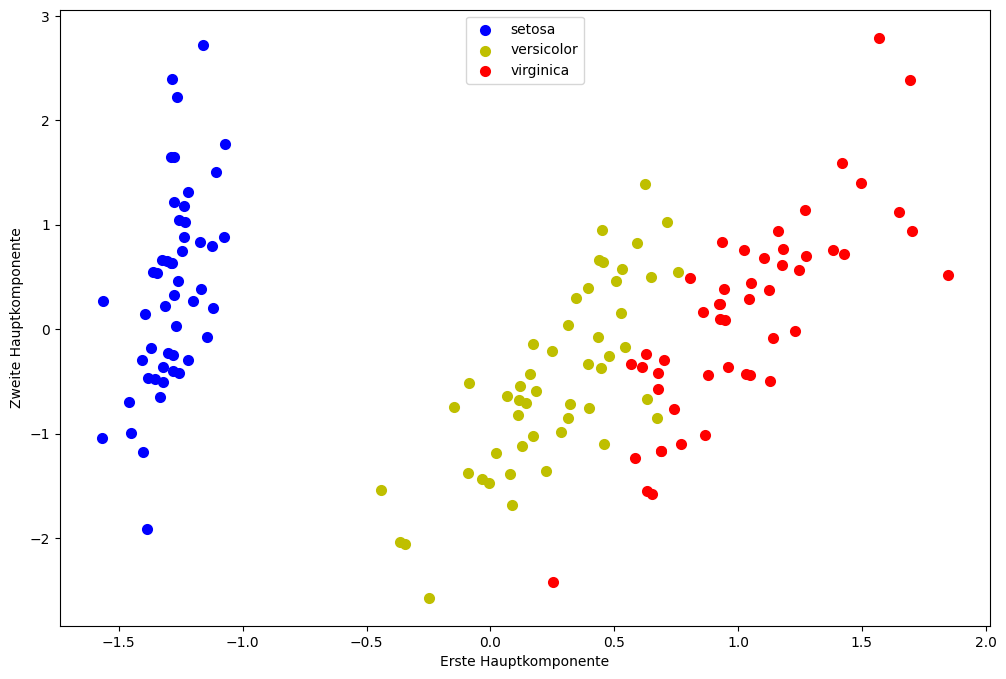

In [53]:
from sklearn.decomposition import PCA

n_classes = 3
colors = 'byr'
CMAP = colors

Y_target_names = iris.target_names


pca = PCA(n_components=2, whiten=True)
pca.fit(X)

# Plot
fig = plt.figure(figsize=(12, 8))

X_pca = pca.transform(X)

for i, color in zip(range(n_classes), colors):
    idx = np.where(y == i)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label = Y_target_names[i],  c=color, lw=2, cmap=CMAP)

plt.xlabel("Erste Hauptkomponente")
plt.ylabel("Zweite Hauptkomponente")
plt.legend(loc='upper center')

plt.show()

In [40]:
pca = PCA(n_components=4, whiten=True)
pca.fit(X)

eigenvalues = pca.singular_values_
eigenvectors = pca.components_
eigenvariance = pca.explained_variance_ratio_

cumulated_eigenvariance = np.zeros(len(eigenvariance))
for i in range(0, len(eigenvariance)):
    cumulated_eigenvariance[i] = eigenvariance[i]
    if i > 0:
        cumulated_eigenvariance[i] += cumulated_eigenvariance[i-1]

print(eigenvalues)
print(eigenvectors)
print(eigenvariance)
print(cumulated_eigenvariance)

[25.09996044  6.01314738  3.41368064  1.88452351]
[[ 0.36138659 -0.08452251  0.85667061  0.3582892 ]
 [ 0.65658877  0.73016143 -0.17337266 -0.07548102]
 [-0.58202985  0.59791083  0.07623608  0.54583143]
 [ 0.31548719 -0.3197231  -0.47983899  0.75365743]]
[0.92461872 0.05306648 0.01710261 0.00521218]
[0.92461872 0.97768521 0.99478782 1.        ]


In [25]:
len(eigenvariance)

4

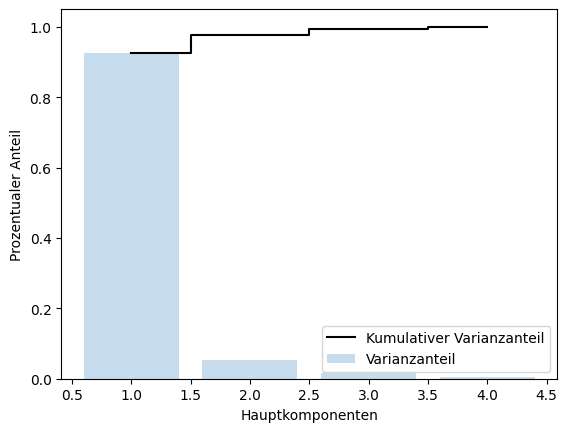

In [39]:
plt.figure()
plt.bar(range(1, len(eigenvariance) + 1), eigenvariance, alpha = 0.25, align = "center", label = "Varianzanteil")
plt.step(range(1, len(eigenvariance) + 1),  cumulated_eigenvariance, where = "mid", label = "Kumulativer Varianzanteil", c = "k")
plt.xlabel("Hauptkomponenten")
plt.ylabel("Prozentualer Anteil")
plt.legend()

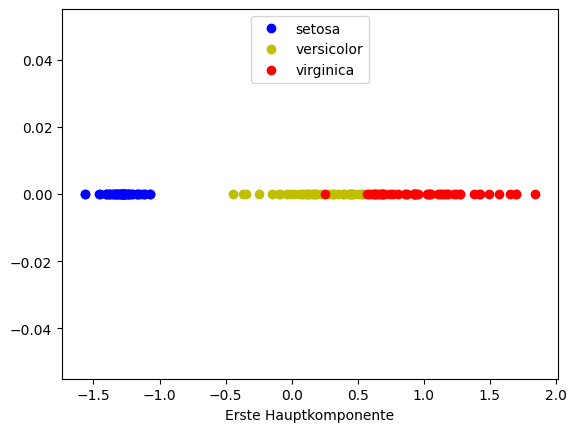

In [54]:
from sklearn.decomposition import PCA

n_classes = 3
colors = 'byr'

Y_target_names = iris.target_names

pca = PCA(n_components=1, whiten=True)
pca.fit(X)
X_pca = pca.transform(X)
val = 0.

for i, color in zip(range(n_classes), colors):
    idx = np.where(y == i)
    plt.plot(X_pca[idx], np.zeros_like(X_pca[idx]) + val, "o", label = Y_target_names[i], lw = 2, c=color)

plt.xlabel("Erste Hauptkomponente")
plt.legend(loc='upper center')

plt.show()